# Chapter 5: Multi-Token Prediction and FP8 Quantization

We have now established the core architectural pillars of the DeepSeek model: Multi-Head Latent Attention and Mixture-of-Experts. These innovations define *what* the model computes. Now, we turn our attention to an equally important topic that defines *how* these computations are performed with incredible efficiency.

This chapter covers two key techniques central to DeepSeek's training methodology:

1. **Multi-Token Prediction (MTP)** — A technique that provides stronger training signals by predicting multiple future tokens simultaneously
2. **FP8 Quantization** — An advanced quantization framework that trades precision for significant gains in speed and memory

This chapter is divided into two main parts. First, we will dive deep into MTP, understanding its motivation, advantages, and exactly how DeepSeek implemented their advanced, causal version of it. After mastering MTP, we will move to the second part, a deep dive into the FP8 Quantization framework.

## Required Libraries

Let's begin by importing the necessary Python libraries:

- `math`: For mathematical operations
- `typing.Optional`: For type hints with optional parameters
- `torch`: PyTorch library for tensor operations and neural networks
- `torch.nn`: Neural network modules and functions
- `torch.nn.functional`: Functional interface for neural network operations

In [1]:
import math
from typing import Optional

import torch
import torch.nn as nn
import torch.nn.functional as F

---

# Part 1: Multi-Token Prediction (MTP)

## From Single-Token to Multi-Token Prediction

The entire training process for the language models we've discussed so far has been based on a single, simple objective: **Next-Token Prediction**. In the standard approach, the model's goal is to predict the single token that immediately follows each input token.

**Multi-Token Prediction** changes this fundamental objective. Instead of predicting only the single next token, the model is trained to predict **multiple future tokens at once**. For example, from the input token "is," it might predict the sequence "transforming," "the," "world."

### The Four Key Advantages of MTP

1. **Densification of training signals** — Each training sample contains much more information for the model to learn from, as it receives gradient signals across multiple future steps simultaneously.

2. **Improved data efficiency** — Since each training sample is more informative, the model achieves higher performance with the same amount of training data. The original MTP paper demonstrated this on coding benchmarks like MBPP and HumanEval.

3. **Better planning by prioritizing "choice points"** — The MTP loss implicitly assigns higher weights to critical tokens that significantly influence the future outcome, forcing the model to develop better internal representations for planning.

4. **Higher inference speed via speculative decoding** — MTP heads can serve as a "draft" model for speculative decoding, achieving up to 3x speedups on certain tasks.

## The DeepSeek MTP Architecture

While the original MTP paper from Meta proved the concept's effectiveness using **independent** output heads, DeepSeek recognized a key opportunity for improvement. Their implementation is designed to **sequentially** predict additional tokens and keep the complete causal chain at each prediction depth.

### Key Design Principles:

1. **Starting Point**: The Shared Transformer Trunk processes input tokens to produce the initial hidden states $h^0$
2. **Sequential Chain**: A series of MTP Modules are chained together, each producing a refined hidden state for the next
3. **Each MTP Module**:
   - Takes the hidden state from the previous step ($h^{k-1}_i$) and the embedding of the future token ($\text{Emb}(t_{i+k})$)
   - Normalizes both via RMSNorm, concatenates, and projects back to model dimension
   - Passes through a dedicated Transformer block
   - Outputs a refined hidden state that serves dual purpose: passed to next head AND projected to vocabulary logits

### The Key Equations:

**Equation 5.1** — Merge and project:
$$h'^k_i = M_k[\text{RMSNorm}(h^{k-1}_i) \; ; \; \text{RMSNorm}(\text{Emb}(t_{i+k}))]$$

**Equation 5.2** — Transformer refinement:
$$h^k_i = \text{TRM}_k(h'^k_i)$$

**Equation 5.3** — Token prediction:
$$P^k_{i+k+1} = \text{OutHead}(h^k_i)$$

The total loss is the sum of the main next-token prediction loss and the weighted average of all MTP losses:
$$\mathcal{L} = \mathcal{L}_{\text{main}} + \frac{\lambda}{D} \sum_{k=1}^{D} \mathcal{L}^k_{\text{MTP}}$$

## Implementing a Causal Multi-Token Prediction Module from Scratch

We will build the entire MTP system in stages:

1. **RMSNorm**: The normalization layer used throughout the DeepSeek architecture
2. **The MTP Module**: The core component that processes one step in the causal chain
3. **The Main Model**: A wrapper class that integrates the main Transformer trunk and the chain of MTP modules
4. **The Forward Pass & Loss**: The complete logic for sequential prediction and the combined loss calculation

### Listing 5.1: RMSNorm

We begin by defining RMSNorm (Root Mean Square Layer Normalization), the specific normalization layer used throughout the DeepSeek architecture. This is a foundational utility that ensures numerical stability during training.

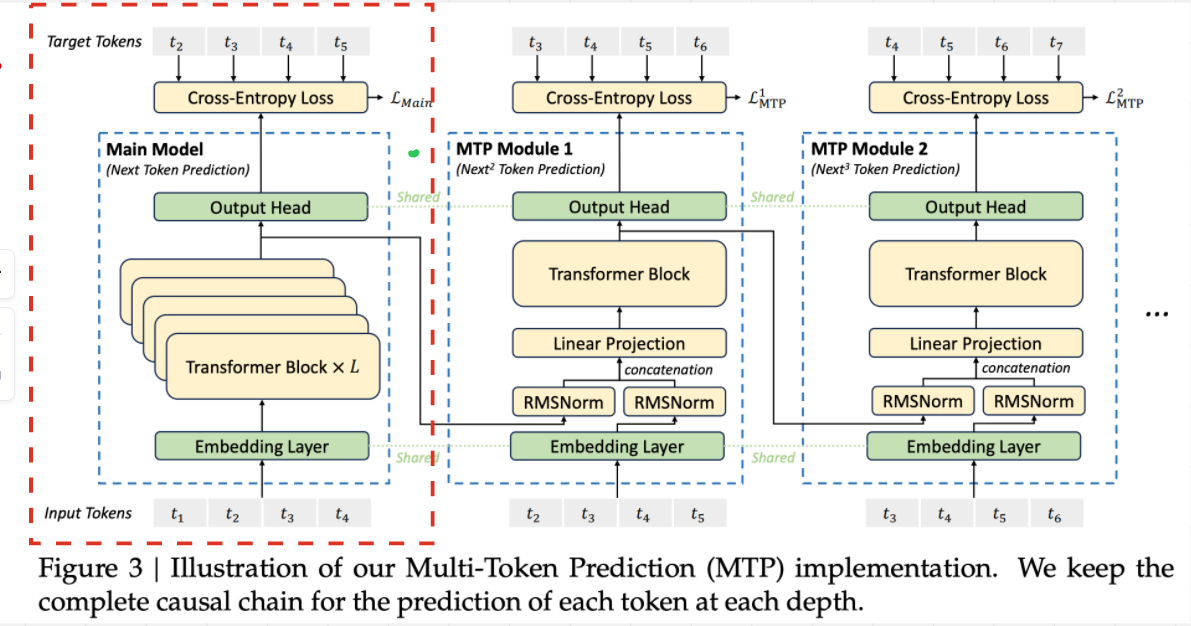

In [2]:
class RMSNorm(nn.Module):
    """
    Implements Root Mean Square Layer Normalization.
    """
    def __init__(self, d_model: int, eps: float = 1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(d_model))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Calculate the inverse square root of the mean of squares
        norm_x = x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)
        # Apply the learnable weight
        return self.weight * norm_x

### Listing 5.2: The Causal MTP Module

Next, we build the core of the MTP architecture: the `DeepSeekMTPModule`. It contains a single, dedicated Transformer block and the necessary projection layers. Its purpose is to take the hidden state from the previous step and the embedding of the next token, and produce a refined hidden state for the next step in the causal chain.

This class is a direct implementation of the logic from Equations 5.1 and 5.2:

1. **Normalize** both the previous hidden state and the future token embedding via separate RMSNorm layers
2. **Concatenate** them to form a merged embedding of dimension $2d$
3. **Project** back down to dimension $d$ via the projection matrix $M_k$
4. **Refine** through a dedicated Transformer block to produce the new hidden state

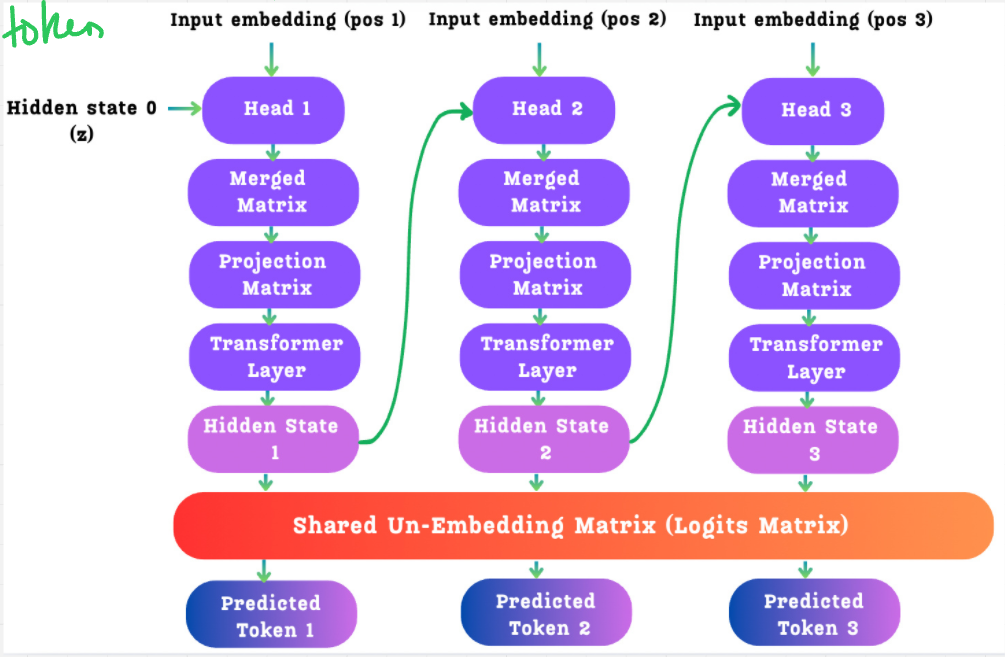

In [3]:
class DeepSeekMTPModule(nn.Module):
    def __init__(self, d_model: int, nhead: int, dim_feedforward: int, dropout: float = 0.0):
        super().__init__()
        self.d_model = d_model

        self.projection_matrix = nn.Linear(2 * d_model, d_model, bias=False)

        self.transformer_block = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True
        )

        self.norm_hidden = RMSNorm(d_model)
        self.norm_embed = RMSNorm(d_model)

    def forward(self, h_prev: torch.Tensor, future_token_embeds: torch.Tensor) -> torch.Tensor:
        h_normed = self.norm_hidden(h_prev)
        embed_normed = self.norm_embed(future_token_embeds)

        concatenated = torch.cat([h_normed, embed_normed], dim=-1)
        h_prime = self.projection_matrix(concatenated)

        h_output = self.transformer_block(h_prime)

        return h_output

### Listings 5.3 & 5.4: The Full MTP Model Architecture with Forward Pass

Now that we have our `DeepSeekMTPModule` building block, we can assemble the full model. Pay close attention to how the different components are organized:

- A **shared embedding** layer (`shared_embed`) used by both the main trunk and all MTP modules
- A **shared output head** (`shared_lm_head`) with **weight tying** to the embedding layer
- The main **Transformer backbone** (Shared Transformer Trunk)
- A **list of MTP modules**, one for each prediction depth

The `forward` method implements the complete sequential MTP process:

1. Input tokens pass through the main Transformer trunk to produce `h_main`
2. A loop iterates through each MTP module in the chain
3. For each depth $k$, the hidden state from the previous step and the ground-truth embedding of the $k$-th future token generate the new hidden state
4. The logits for each future token are computed from the refined hidden state
5. The total loss combines the main next-token prediction loss with the weighted average of MTP losses:

$$\mathcal{L} = \mathcal{L}_{\text{main}} + \frac{\lambda}{D} \sum_{k=1}^{D} \mathcal{L}^k_{\text{MTP}}$$

In [4]:
class DeepSeekV3WithMTP(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        d_model: int,
        num_layers: int,
        nhead: int,
        num_mtp_heads: int,                         # D (number of MTP depths)
        dim_feedforward: int,
        dropout: float = 0.0,
        mtp_loss_weight: float = 0.1
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.num_layers = num_layers
        self.nhead = nhead
        self.num_mtp_heads = num_mtp_heads
        self.dim_feedforward = dim_feedforward
        self.dropout = dropout
        self.mtp_loss_weight = mtp_loss_weight

        # Shared components used across the model
        self.shared_embed = nn.Embedding(vocab_size, d_model)
        self.shared_lm_head = nn.Linear(d_model, vocab_size, bias=False)

        # Main transformer backbone (Shared Transformer Trunk)
        self.blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
                dropout=dropout, activation='gelu', batch_first=True,
                norm_first=True
            )
            for _ in range(num_layers)
        ])
        self.norm_f = RMSNorm(d_model)

        # Weight tying between embedding and output head
        self.shared_lm_head.weight = self.shared_embed.weight

        # The chain of MTP modules
        self.mtp_modules = nn.ModuleList([
            DeepSeekMTPModule(d_model, nhead, dim_feedforward, dropout)
            for _ in range(num_mtp_heads)
        ])

    def get_embedding(self, input_ids: torch.Tensor) -> torch.Tensor:
        """
        Shared embedding lookup used by the main trunk and all MTP modules.
        """
        return self.shared_embed(input_ids)

    def get_output_logits(self, hidden_states: torch.Tensor) -> torch.Tensor:
        """
        Shared un-embedding matrix that projects hidden states to vocabulary logits.
        """
        return self.shared_lm_head(hidden_states)

    def forward(self, input_ids: torch.Tensor, targets: Optional[torch.Tensor] = None):
        B, S = input_ids.shape

        # --- Main model forward pass ---
        x = self.get_embedding(input_ids)
        for block in self.blocks:
            x = block(x)
        h_main = self.norm_f(x)
        logits_main = self.get_output_logits(h_main)

        all_logits = [logits_main]
        h_prev = h_main

        # --- MTP chain: Sequential prediction ---
        for depth_k in range(1, self.num_mtp_heads + 1):
            L = S - depth_k
            if L <= 0: break

            h_prev_sliced = h_prev[:, :L, :]

            future_token_ids = input_ids[:, depth_k:depth_k + L]
            future_token_embeds = self.get_embedding(future_token_ids)

            h_curr = self.mtp_modules[depth_k - 1](h_prev_sliced, future_token_embeds)

            logits_k = self.get_output_logits(h_curr)
            all_logits.append(logits_k)

            h_prev = h_curr

        # --- Loss computation ---
        loss = None
        if targets is not None:
            # Main model loss (standard next-token prediction)
            shift_logits = logits_main[:, :-1, :].contiguous()
            shift_targets = targets[:, 1:].contiguous()
            total_loss = F.cross_entropy(
                shift_logits.view(-1, self.vocab_size),
                shift_targets.view(-1)
            )

            mtp_loss_sum = 0.0
            for k, logits_k in enumerate(all_logits[1:], start=1):
                # MTP head k at position i predicts token at position i+k+1
                mtp_logits = logits_k[:, :-1, :].contiguous()
                mtp_targets = targets[:, k + 1:k + 1 + mtp_logits.size(1)].contiguous()
                if mtp_targets.numel() == 0:
                    continue
                loss_mtp_k = F.cross_entropy(
                    mtp_logits.view(-1, self.vocab_size),
                    mtp_targets.view(-1)
                )
                mtp_loss_sum += loss_mtp_k

            # Final loss: L = L_main + (lambda/D) * sum(L_MTP^k)
            if self.num_mtp_heads > 0 and mtp_loss_sum > 0:
                mtp_loss_weighted = (self.mtp_loss_weight / self.num_mtp_heads) * mtp_loss_sum
                total_loss += mtp_loss_weighted

            loss = total_loss

        return {"logits_all": all_logits, "loss": loss}

### Understanding the MTP Forward Pass

The forward method above contains the complete MTP logic. Let's trace through what happens:

**Main Trunk:**
- Input tokens are embedded and passed through the stack of Transformer blocks
- The output `h_main` (Hidden State 0, or $h^0$) is our starting point
- The main logits predict the immediate next token at each position

**MTP Chain:**
- For each depth `k` from 1 to D:
  - Slice `h_prev` to length `S - k` (accounting for the causal offset)
  - Get the ground-truth embeddings for the `k`-th future tokens
  - Pass both through the `k`-th MTP module to get refined hidden state `h_curr`
  - Compute logits from `h_curr` using the **shared** output head
  - `h_curr` becomes `h_prev` for the next depth — this is the **causal chain**

**Loss Calculation:**
- The main loss uses standard next-token prediction (shifted by 1)
- Each MTP head's loss is computed for its corresponding future token target
- The final loss combines them: $\mathcal{L} = \mathcal{L}_{\text{main}} + \frac{\lambda}{D} \sum_k \mathcal{L}^k_{\text{MTP}}$

Notice how the sequence length of the logit tensors **decreases by one at each step**, confirming the causal chain is correctly implemented.

### Listing 5.5: Verifying the Causal MTP Implementation

Let's verify our implementation by creating a model with:
- `vocab_size = 1000`
- `d_model = 128` with `nhead = 8`
- `num_layers = 6` Transformer blocks
- `num_mtp_heads = 3` (D=3, predict next 3 tokens)

We'll pass a batch of random token IDs through the model and verify the output shapes.

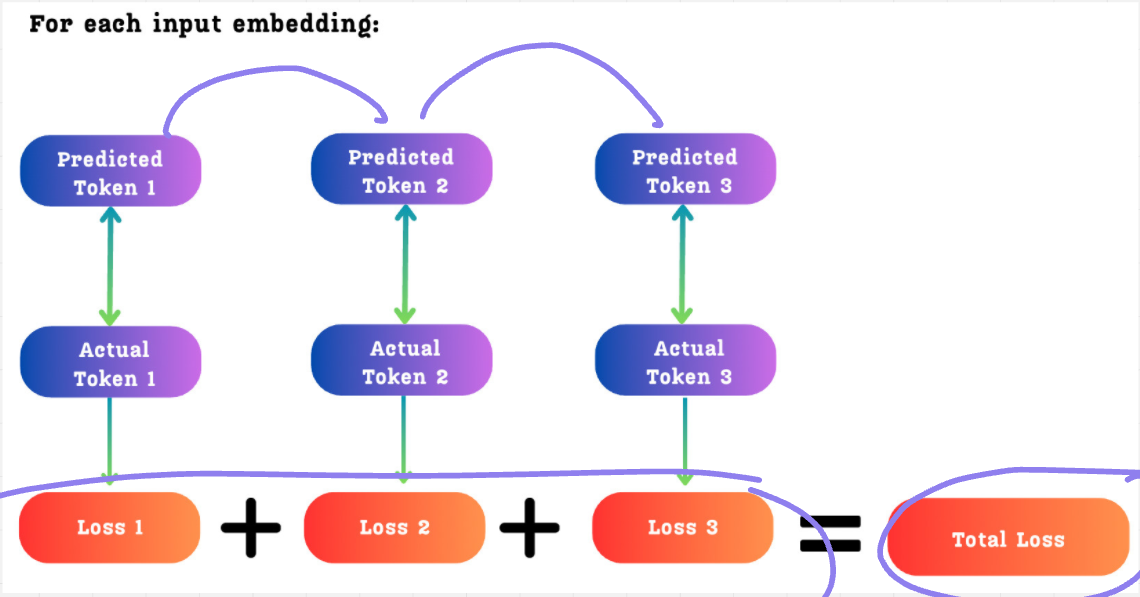

In [5]:
def verify_deepseek_v3_mtp():
    # --- Model configuration ---
    vocab_size = 1000
    d_model = 128
    num_layers = 6
    nhead = 8
    num_mtp_heads = 3  # D=3 (predict next 3 tokens)
    dim_feedforward = 512
    mtp_loss_weight = 0.1

    model = DeepSeekV3WithMTP(
        vocab_size=vocab_size, d_model=d_model, num_layers=num_layers,
        nhead=nhead, num_mtp_heads=num_mtp_heads,
        dim_feedforward=dim_feedforward, mtp_loss_weight=mtp_loss_weight
    )
    print(f"Model created with {sum(p.numel() for p in model.parameters())/1e6:.2f}M params")

    # --- Test data ---
    batch_size = 2
    seq_len = 20
    input_ids = torch.randint(0, vocab_size, (batch_size, seq_len))

    # --- Forward pass and output verification ---
    outputs = model(input_ids, targets=input_ids)
    all_logits = outputs['logits_all']
    loss = outputs['loss']

    print("\nLogits shapes:")
    for i, logits in enumerate(all_logits):
        pred_type = "Main" if i == 0 else f"MTP k={i}"
        print(f"  {pred_type:10}: {list(logits.shape)}")

    print(f"\nTotal loss: {loss.item():.4f}")


verify_deepseek_v3_mtp()

Model created with 2.01M params

Logits shapes:
  Main      : [2, 20, 1000]
  MTP k=1   : [2, 19, 1000]
  MTP k=2   : [2, 18, 1000]
  MTP k=3   : [2, 17, 1000]

Total loss: 110.1269


Running this script produces output like the following. Notice how the **sequence length** (the middle dimension) of the logit tensors **decreases by one at each step**, confirming our causal chain is correctly implemented:

```
Model created with 2.01M params

Logits shapes:
  Main      : [2, 20, 1000]
  MTP k=1   : [2, 19, 1000]
  MTP k=2   : [2, 18, 1000]
  MTP k=3   : [2, 17, 1000]

Total loss: 109.1470
```

**Key observations:**
- The model has ~2.01M parameters (appropriate for our demonstration scale)
- Main logits: `[2, 20, 1000]` — full sequence length, vocabulary size 1000
- MTP k=1: `[2, 19, 1000]` — one fewer position (offset by 1)
- MTP k=2: `[2, 18, 1000]` — two fewer positions
- MTP k=3: `[2, 17, 1000]` — three fewer positions
- The total loss combines the main loss with the weighted MTP losses

> **Note:** The exact loss value may vary depending on PyTorch version and random initialization.